# 18. Model Insights

## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT782  
**Prepared by:** Khalid Ameen  

**Project Team:**  
- Suba (225094537)  
- Burhan (224802775)  
- Khalid (224696667)  


**Task:** Model Insights, Discussion, Limitations, and Future Improvements (Week 8 of 8)

This notebook continues from `17_advanced_models.ipynb`. It focuses on interpreting the advanced modelling results and preparing report-ready insights for the final TARP submission.

The notebook reviews the behaviour of the selected models, especially:

- Random Forest
- XGBoost

The main focus is on understanding which features influenced accident severity prediction, how the models behaved across different severity classes, and why predicting **Fatal accident** remained challenging due to strong class imbalance.

This notebook also prepares discussion points, limitations, and future improvement notes to support the final report and presentation.

## Objective

This notebook supports the Week 8 finalisation stage of the TARP project by summarising model insights from the advanced modelling work.

The notebook focuses on:

- reviewing feature importance outputs from Random Forest and XGBoost
- creating clear feature importance visuals for reporting and dashboard use
- interpreting model behaviour in relation to accident severity prediction
- discussing model strengths, weaknesses, and class-wise performance
- identifying key limitations of the current modelling approach
- suggesting future improvements for later project development

## Output

- feature importance comparison visuals
- interpretation notes for model behaviour
- discussion points for the final report
- limitations section draft
- future improvement section draft

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define File Paths

This notebook uses output files generated from the Week 7 advanced modelling notebook.

In [3]:
project_root = Path(
    r"D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction"
)

output_dir = project_root / "outputs"

print("Project root:", project_root.resolve())
print("Using output directory:", output_dir.resolve())

if not output_dir.exists():
    raise FileNotFoundError(f"Output folder not found: {output_dir.resolve()}")

Project root: D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction
Using output directory: D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs


## 3. Load Model Output Files

In [4]:
all_model_file = output_dir / "all_model_comparison.csv"
advanced_model_file = output_dir / "advanced_model_comparison.csv"
classwise_file = output_dir / "advanced_classwise_performance.csv"
rf_importance_file = output_dir / "random_forest_feature_importance.csv"
xgb_importance_file = output_dir / "xgboost_feature_importance.csv"

all_model_results = pd.read_csv(all_model_file)
advanced_results = pd.read_csv(advanced_model_file)
classwise_results = pd.read_csv(classwise_file)
rf_feature_importance = pd.read_csv(rf_importance_file)
xgb_feature_importance = pd.read_csv(xgb_importance_file)

print("Files loaded successfully.")

Files loaded successfully.


## 4. Review Overall Model Comparison

In [5]:
all_model_results

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.451102,0.364228,0.449774,0.314139,0.557436,0.451102,0.484276
1,Decision Tree,0.459526,0.364736,0.442278,0.323380,0.556985,0.459526,0.493191
2,Random Forest,0.518756,0.374305,0.437510,0.357419,0.564031,0.518756,0.533743
3,XGBoost,0.480520,0.366265,0.447649,0.332384,0.557587,0.480520,0.505370


### Interpretation

The overall model comparison shows that the advanced models improved performance compared with the baseline models. Logistic Regression and Decision Tree provided the initial benchmark, while Random Forest and XGBoost were trained as advanced models in Week 7.

Random Forest achieved the strongest overall performance, with the highest accuracy, macro F1-score, and weighted F1-score among all tested models. This indicates that Random Forest provided the best overall balance across the evaluation metrics.

XGBoost also improved over the baseline models, particularly in weighted F1-score, but it did not outperform Random Forest overall. However, XGBoost remained useful because it achieved higher recall for the Fatal accident class, which is important from a safety-focused perspective.

Overall, this comparison supports the selection of Random Forest as the preferred final model, while also showing that fatal accident prediction remains a key area for future improvement.

## 5. Review Class-wise Model Performance

In [6]:
classwise_results

,Model,Class,Precision,Recall,F1-score,Support
0,Random Forest,Fatal accident,0.044186,0.374753,0.079051,507.0
1,Random Forest,Other injury accident,0.668132,0.670048,0.669089,18827.0
2,Random Forest,Serious injury accident,0.410598,0.267728,0.324117,11056.0
3,XGBoost,Fatal accident,0.038544,0.495069,0.071520,507.0
4,XGBoost,Other injury accident,0.669591,0.640569,0.654759,18827.0
5,XGBoost,Serious injury accident,0.390660,0.207308,0.270874,11056.0


### Fatal Accident Performance

The class-wise results show that **Fatal accident** remains the most difficult severity class to predict. This is mainly because it has very low representation in the dataset, with only 507 fatal accident records in the test set. Because the models have fewer fatal examples to learn from, prediction performance for this class is weaker than for the majority class.

For Fatal accident, **Random Forest** achieved a precision of 0.044, recall of 0.375, and F1-score of 0.079. **XGBoost** achieved a precision of 0.039, recall of 0.495, and F1-score of 0.072. This means XGBoost detected more actual fatal accident cases, but it also produced more false positives.

The results show a trade-off between fatal accident detection and overall model balance. XGBoost was more sensitive to fatal accident cases, while Random Forest provided stronger overall performance and a slightly better Fatal accident F1-score. For this reason, Random Forest was selected as the final model, while improving Fatal accident prediction remains an important future improvement area.

Overall, both models performed best on the **Other injury accident** class because it is the majority class. Performance for **Serious injury accident** was moderate, while **Fatal accident** was the weakest class due to strong class imbalance. This confirms that class-wise evaluation is necessary because accuracy alone does not show how well the models handle rare but safety-critical accident outcomes.

## 6. Random Forest Feature Importance

In [7]:
rf_feature_importance

,Feature,Importance
0,speed_zone_numeric,0.316591
1,Min temperature (°C),0.108772
2,Max temperature (°C),0.106140
3,pedestrian_density,0.093509
4,Max Humidity (%),0.090413
5,bicycle_density,0.080423
6,max wind speed (km/h),0.068850
7,hour_of_day,0.065471
8,Total Rainfall (mm),0.047663
9,rush_hour,0.011826


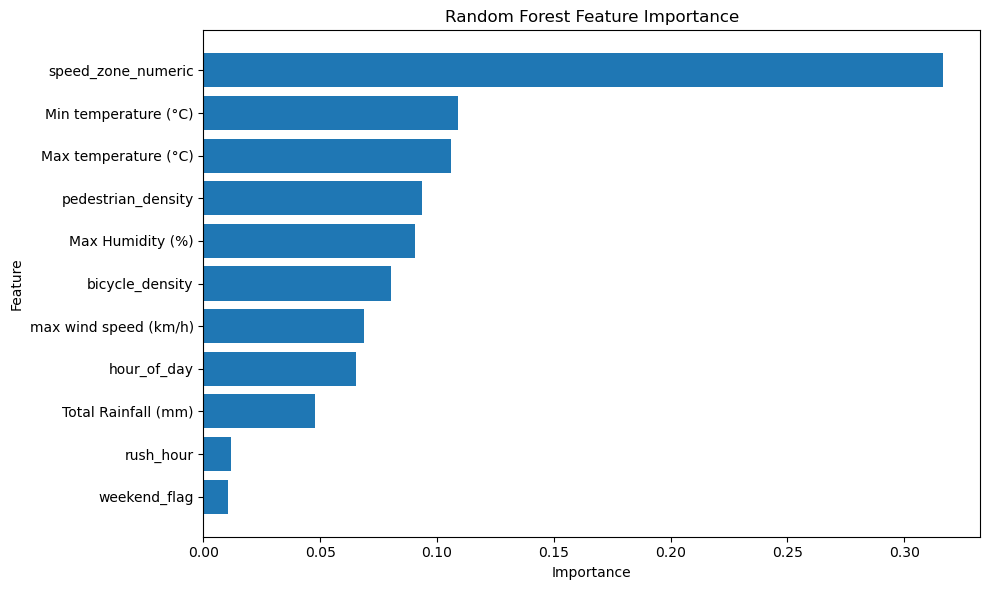

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance["Feature"], rf_feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Random Forest Feature Importance Interpretation

The Random Forest feature importance results show that `speed_zone_numeric` was the strongest predictor by a clear margin. This means the speed zone or road speed environment had the largest influence on the model’s accident severity predictions.

After speed zone, the next most important features were weather and mobility-related variables, including minimum temperature, maximum temperature, pedestrian density, humidity, bicycle density, wind speed, and hour of day. This suggests that the model did not rely on one type of feature only, but used a combination of road, weather, mobility, and temporal factors.

Features such as `rush_hour` and `weekend_flag` had the lowest importance in the Random Forest model. This does not mean they are useless, but it suggests that they contributed less to prediction compared with speed zone and the environmental or mobility-related features.

Overall, the Random Forest results support one of the key project findings: **speed zone is the most influential feature for predicting accident severity**, while other weather, mobility, and time-based factors provide additional supporting information.

## 7. XGBoost Feature Importance

In [9]:
xgb_feature_importance

,Feature,Importance
0,speed_zone_numeric,0.419487
1,rush_hour,0.093633
2,hour_of_day,0.070747
3,pedestrian_density,0.063388
4,bicycle_density,0.060313
5,Max temperature (°C),0.052221
6,Max Humidity (%),0.050202
7,Min temperature (°C),0.049402
8,max wind speed (km/h),0.048399
9,Total Rainfall (mm),0.047564


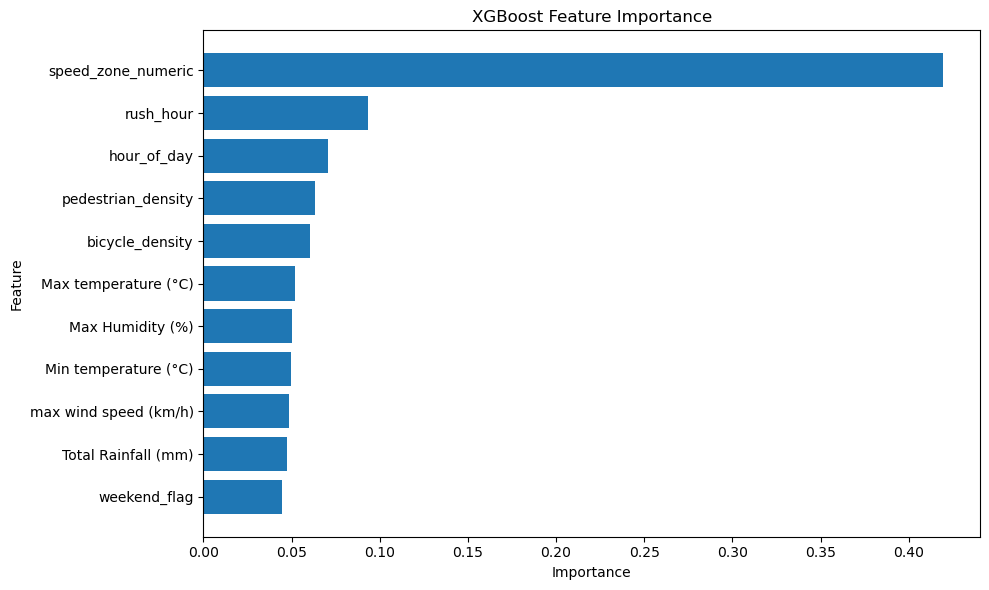

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(xgb_feature_importance["Feature"], xgb_feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### XGBoost Feature Importance Interpretation

The XGBoost feature importance results also show that `speed_zone_numeric` was the most important feature by a large margin. This confirms the same key finding seen in the Random Forest model: road speed conditions are strongly linked with accident severity prediction.

Compared with Random Forest, XGBoost relied even more heavily on `speed_zone_numeric`. The next most important features were `rush_hour`, `hour_of_day`, `pedestrian_density`, and `bicycle_density`. This suggests that XGBoost placed more emphasis on road speed, time-based conditions, and mobility-related patterns.

Weather-related features such as temperature, humidity, wind speed, and rainfall still contributed to the model, but they had lower importance compared with speed zone and time/mobility variables. This indicates that weather supports the prediction process, but it is not the strongest driver in this model.

Overall, the XGBoost results reinforce the project finding that `speed_zone_numeric` is the strongest predictor of accident severity. They also show that rush hour, time of day, pedestrian density, and bicycle density provide useful supporting information for understanding accident risk patterns.

## 8. Feature Importance Comparison

In [11]:
rf_compare = rf_feature_importance.rename(columns={"Importance": "Random Forest Importance"}).copy()
xgb_compare = xgb_feature_importance.rename(columns={"Importance": "XGBoost Importance"}).copy()

feature_comparison = pd.merge(rf_compare, xgb_compare, on="Feature", how="outer").fillna(0)
feature_comparison = feature_comparison.sort_values(
    by=["Random Forest Importance", "XGBoost Importance"],
    ascending=False
)

feature_comparison

,Feature,Random Forest Importance,XGBoost Importance
9,speed_zone_numeric,0.316591,0.419487
2,Min temperature (°C),0.108772,0.049402
1,Max temperature (°C),0.106140,0.052221
7,pedestrian_density,0.093509,0.063388
0,Max Humidity (%),0.090413,0.050202
4,bicycle_density,0.080423,0.060313
6,max wind speed (km/h),0.068850,0.048399
5,hour_of_day,0.065471,0.070747
3,Total Rainfall (mm),0.047663,0.047564
8,rush_hour,0.011826,0.093633


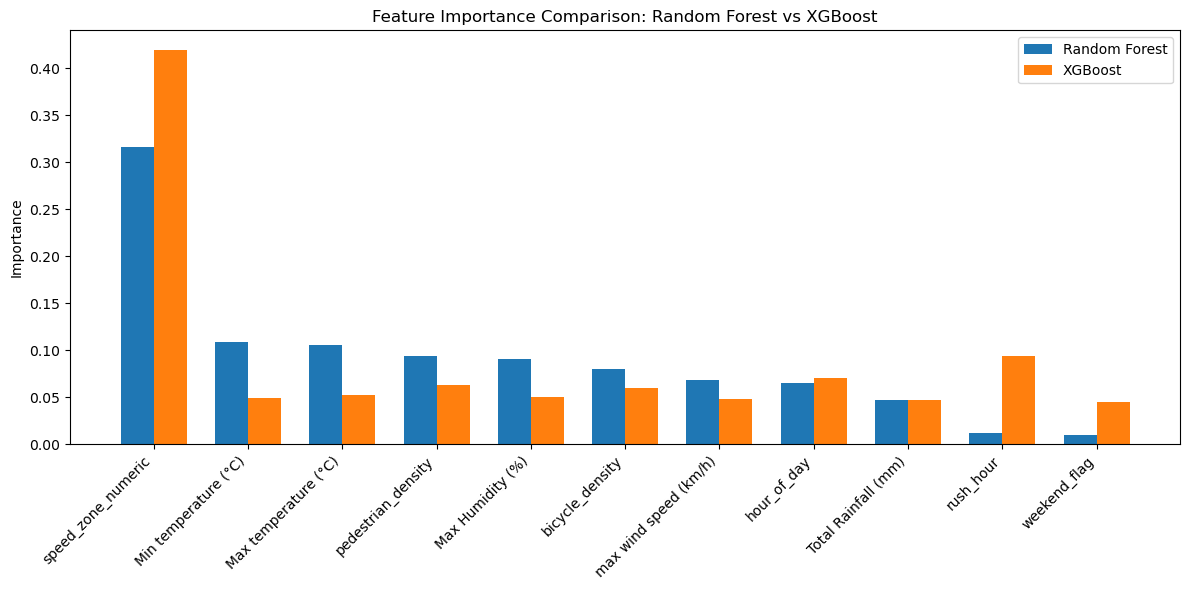

In [12]:
plot_df = feature_comparison.copy()
x = np.arange(len(plot_df["Feature"]))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_df["Random Forest Importance"], width, label="Random Forest")
plt.bar(x + width/2, plot_df["XGBoost Importance"], width, label="XGBoost")
plt.xticks(x, plot_df["Feature"], rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Feature Importance Comparison: Random Forest vs XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance Comparison Interpretation

The feature importance comparison shows that both Random Forest and XGBoost identified `speed_zone_numeric` as the most important feature. This is the strongest and most consistent finding across both advanced models, confirming that speed zone is highly influential in predicting accident severity.

XGBoost placed even greater importance on `speed_zone_numeric` than Random Forest, suggesting that it relied more heavily on this single road-related feature. XGBoost also gave relatively higher importance to `rush_hour`, `hour_of_day`, and `weekend_flag`, showing stronger emphasis on temporal patterns.

Random Forest distributed importance more evenly across several features, including temperature, pedestrian density, humidity, bicycle density, wind speed, and hour of day. This suggests that Random Forest used a broader mix of road, weather, mobility, and time-related factors when making predictions.

Overall, the comparison supports the project finding that accident severity is influenced by multiple factors, but speed zone is the strongest individual predictor. It also explains why Random Forest was selected as the final model: it provided better overall performance while using a more balanced combination of features.

## 9. Discussion Points on Model Behaviour

- The advanced models performed better than the baseline models, showing that non-linear machine learning methods were more suitable for the selected feature set.

- Random Forest provided the strongest overall balance across accuracy, macro F1-score, and weighted F1-score. This supports its selection as the final model.

- XGBoost achieved higher recall for the **Fatal accident** class, meaning it identified more actual fatal accident cases. However, this came with lower precision, meaning it also produced more false positives.

- The **Fatal accident** class remained the most difficult class to predict because it was highly under-represented in the dataset. This confirms the impact of class imbalance on model behaviour.

- Both models performed best on the **Other injury accident** class because it was the majority class and had the largest number of training examples.

- Performance for **Serious injury accident** was moderate, suggesting that the model may have difficulty separating serious injury cases from other injury cases.

- Feature importance results showed that `speed_zone_numeric` was the strongest predictor in both Random Forest and XGBoost. This indicates that road speed conditions are highly relevant to crash severity prediction.

- Random Forest used a broader mix of features, including speed zone, temperature, pedestrian density, humidity, bicycle density, wind speed, and hour of day. This suggests a more balanced use of road, weather, mobility, and temporal information.

- XGBoost relied more heavily on speed zone and gave greater importance to time-related features such as rush hour and hour of day.

- Overall accuracy alone was not sufficient for evaluating the models because the dataset was imbalanced. Macro F1-score and class-wise metrics were necessary to better understand performance across all severity classes.

- The results suggest that advanced models can improve severity prediction, but further work is needed to improve prediction of rare and safety-critical fatal accidents.

## 10. Draft Limitations

- The dataset was highly imbalanced, with **Fatal accident** representing only a small proportion of records. This made fatal accident prediction difficult and reduced the model’s ability to learn clear patterns for this class.

- The models achieved low precision for **Fatal accident**, meaning many cases predicted as fatal were actually other severity classes. This limits the reliability of fatal accident predictions.

- The current models used a selected feature set focused on temporal, speed zone, mobility, and weather-related variables. Additional road, vehicle, driver, and environmental variables may improve prediction quality.

- Some important behavioural and human factors, such as driver distraction, speeding behaviour, fatigue, alcohol involvement, seatbelt use, and driver experience, were not fully captured in the selected modelling features.

- The model outputs should be interpreted as **decision-support insights** rather than exact predictions for individual crashes. The results are more useful for identifying risk patterns than making absolute crash-level decisions.

- Feature importance explains which variables influenced the model, but it does not prove direct causation. For example, speed zone was highly influential, but this does not mean speed zone alone causes severe accidents.

- The project used historical crash and environmental data. Future changes in road conditions, traffic patterns, vehicle technology, and safety policies may affect model performance.

- The model was evaluated using a train-test split. Additional validation methods, such as cross-validation or testing on future unseen data, could provide stronger evidence of generalisability.

- Dashboard visualisations may simplify complex model behaviour and should be interpreted alongside the notebook results, model evaluation outputs, and final report discussion.

- The current modelling results show useful patterns, but further tuning and additional data would be needed before using the model in a real-world operational road safety setting.

## 11. Draft Future Improvements

- Apply additional class imbalance techniques such as SMOTE, undersampling, oversampling, balanced class weights, or threshold tuning to improve prediction of the rare **Fatal accident** class.

- Test additional algorithms such as LightGBM, CatBoost, balanced Random Forest, or ensemble stacking to assess whether they provide stronger performance than the current models.

- Perform more detailed hyperparameter tuning for Random Forest and XGBoost to improve overall model performance and class-wise prediction quality.

- Add more crash-level features, such as vehicle type, road surface condition, lighting condition, traffic control type, driver behaviour, and contributing factors.

- Include more detailed spatial features, such as road segment risk, intersection density, traffic volume, nearby land-use characteristics, and distance to high-risk locations.

- Use cross-validation and, where possible, future unseen data to improve confidence in model generalisability.

- Develop a more interactive dashboard that allows users to filter by year, region, severity, speed zone, weather status, road-user type, and model outputs.

- Add explainability methods such as SHAP values to better understand how features influence individual model predictions.

- Explore separate modelling approaches for **Fatal accident** prediction because fatal crashes are rare, safety-critical, and may require more targeted modelling methods.

- Update and retrain the model regularly as new accident data, road changes, traffic patterns, and safety policy changes become available.

- Investigate whether additional external datasets, such as traffic volume, road infrastructure, enforcement activity, or event data, can improve prediction quality.

## 12. Final Summary

This notebook prepared model insight materials for the Week 8 finalisation stage of the TARP project. It reviewed feature importance results, compared Random Forest and XGBoost model behaviour, discussed class-wise performance, and prepared report-ready limitations and future improvement points.

The feature importance analysis confirmed that `speed_zone_numeric` was the strongest predictor in both advanced models. Other weather, mobility, and time-related features also contributed to the model decisions, but they were less influential than speed zone.

The main conclusion is that Random Forest remains the preferred final model because it achieved the strongest overall performance across the key evaluation metrics. However, **Fatal accident** prediction remains the main modelling challenge due to strong class imbalance and the limited number of fatal crash records.

Overall, this notebook supports the final report, dashboard development, and presentation preparation by summarising the key modelling insights, limitations, and future directions for the project.